QUESTION 3: RISK-SENSITIVE ROBOT NAVIGATION NEAR HAZARDS
Risk-Sensitive Robot Navigation MDP
Grid Size: 10x10
Hazard Zones (h=2): [(2, 4), (2, 5), (3, 4), (3, 5), (4, 3), (4, 4), (4, 5), (4, 6), (5, 3), (5, 4), (5, 5), (5, 6), (6, 4), (6, 5), (7, 4), (7, 5)]
Near-Hazard Zones (h=1): [(1, 4), (1, 5), (2, 3), (2, 6), (3, 3), (3, 6), (4, 2), (4, 7), (5, 2), (5, 7), (6, 3), (6, 6), (7, 3), (7, 6), (8, 4), (8, 5)]
Obstacles: [(1, 2), (8, 7)]
Goal: (9, 9)
Start: (0, 0)
States: 98
Slip probs - Normal: 0.0, Near: 0.1, Hazard: 0.3

    MDP Formulation:
    State Space: S = {(x, y, h) | x,y ∈ [0,9], h ∈ {0,1,2}}
    where h = 0 (normal), h = 1 (near hazard), h = 2 (in hazard zone)
    
    Actions: A = {Up, Down, Left, Right}
    
    Transition Model:
    ┌──────────────┬─────────┬──────────┬─────────────┐
    │ Region       │ Success │ Side Slip│ Catastrophe  │
    ├──────────────┼─────────┼──────────┼─────────────┤
    │ Normal (h=0) │  95%    │  2.5%×2  │    0%       │
    │ Near (h=1)   │  

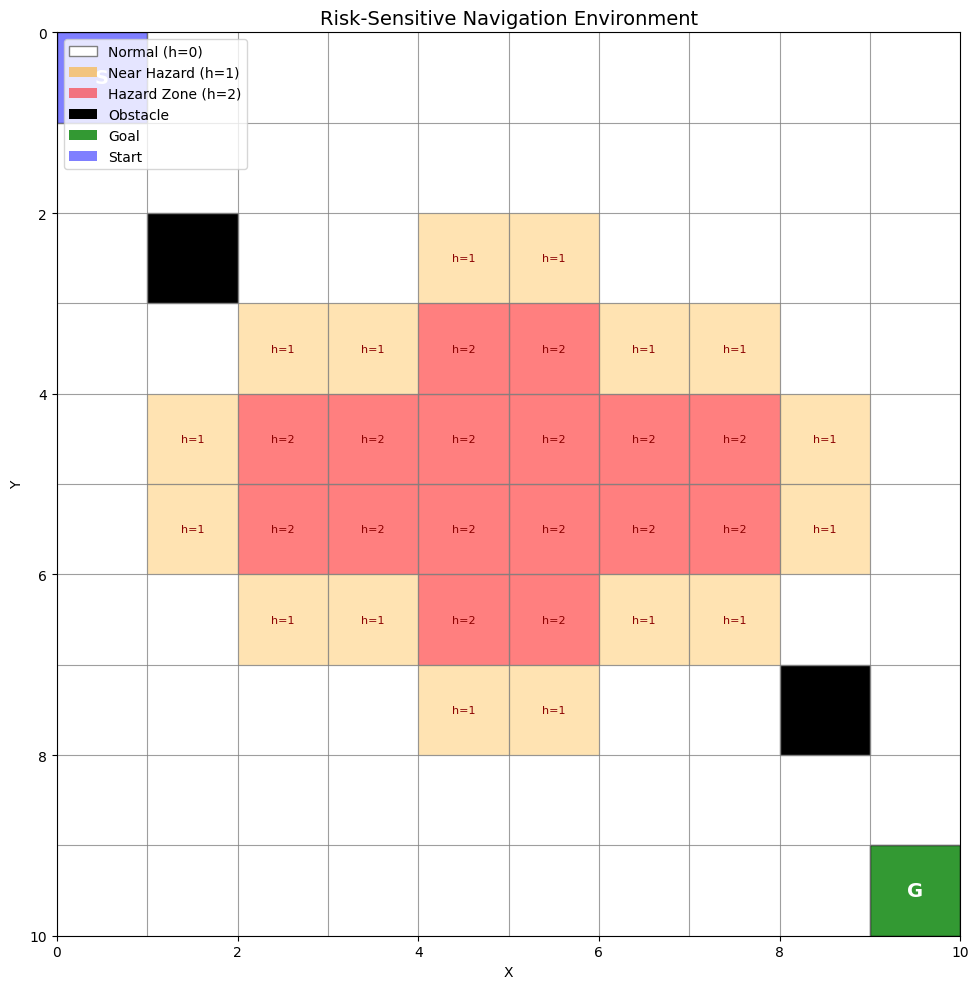

Saved: risk_grid.png

(a) VALUE ITERATION - Original Slip Probabilities

--- Value Iteration ---
Converged in 36 iterations
Runtime: 0.3219 seconds
Peak memory: 18.91 KB

Optimal Policy (VI, Original):
--------------------------------------------------
y\x| 0 1 2 3 4 5 6 7 8 9
--------------------------------------------------
 0 | R R R R R R R R D D 
 1 | D R R R R R R R D D 
 2 | D X U U U U R R R D 
 3 | D L U U U U U U R D 
 4 | D L L U U U U R R D 
 5 | D L D D D D D R R D 
 6 | D D D D D D D D R D 
 7 | D D D D D D D D X D 
 8 | R R R R D D R R R D 
 9 | R R R R R R R R R G 
--------------------------------------------------


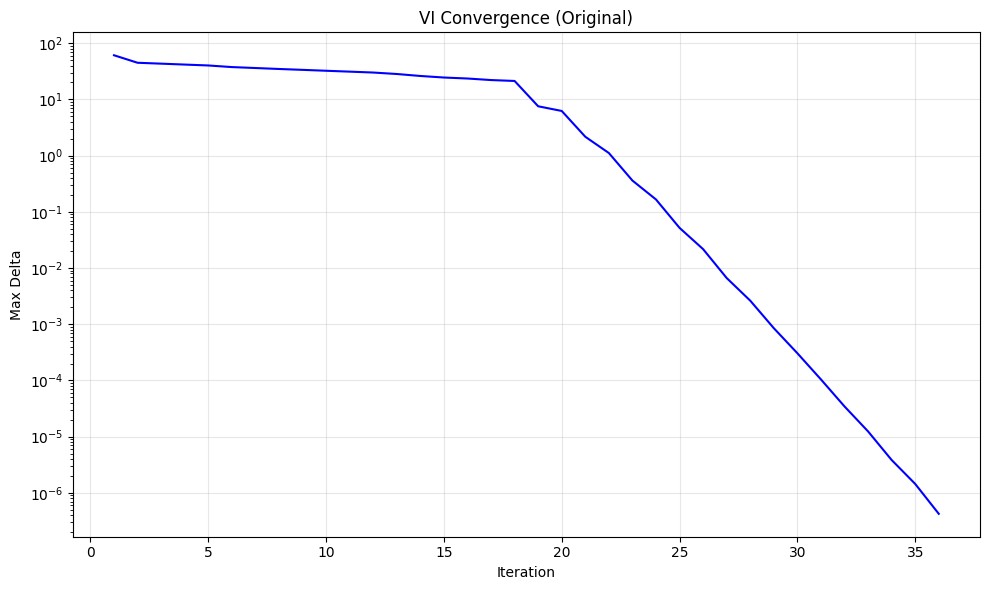

Saved: risk_conv_vi_orig.png


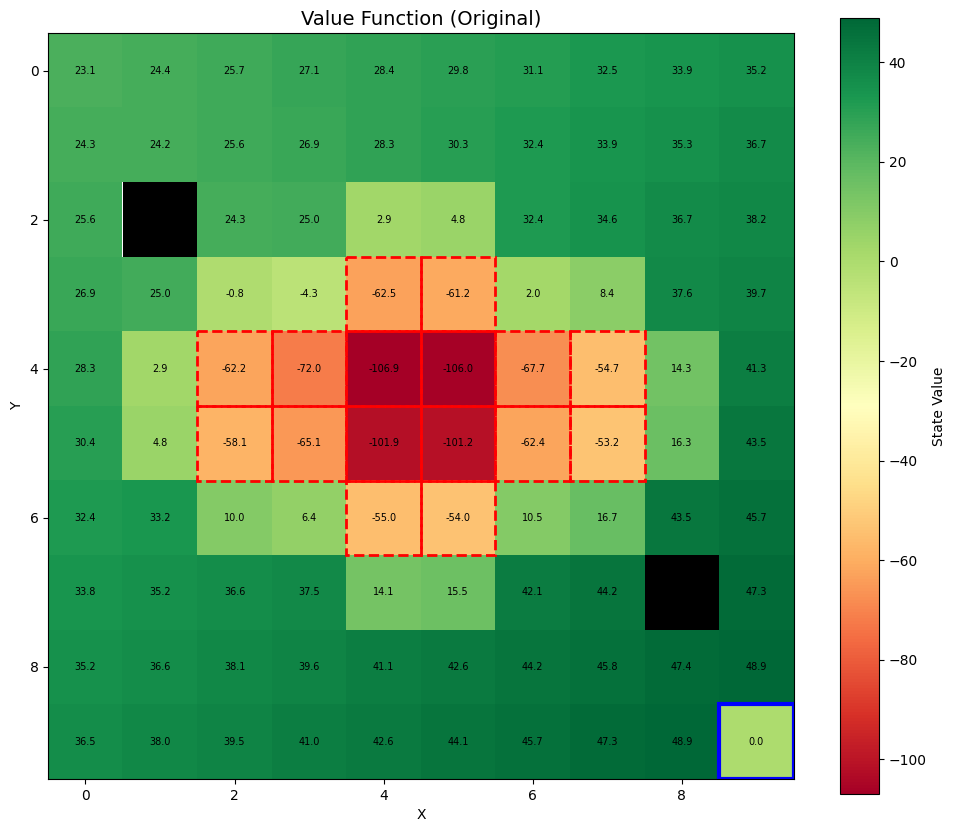

Saved: risk_value_orig.png


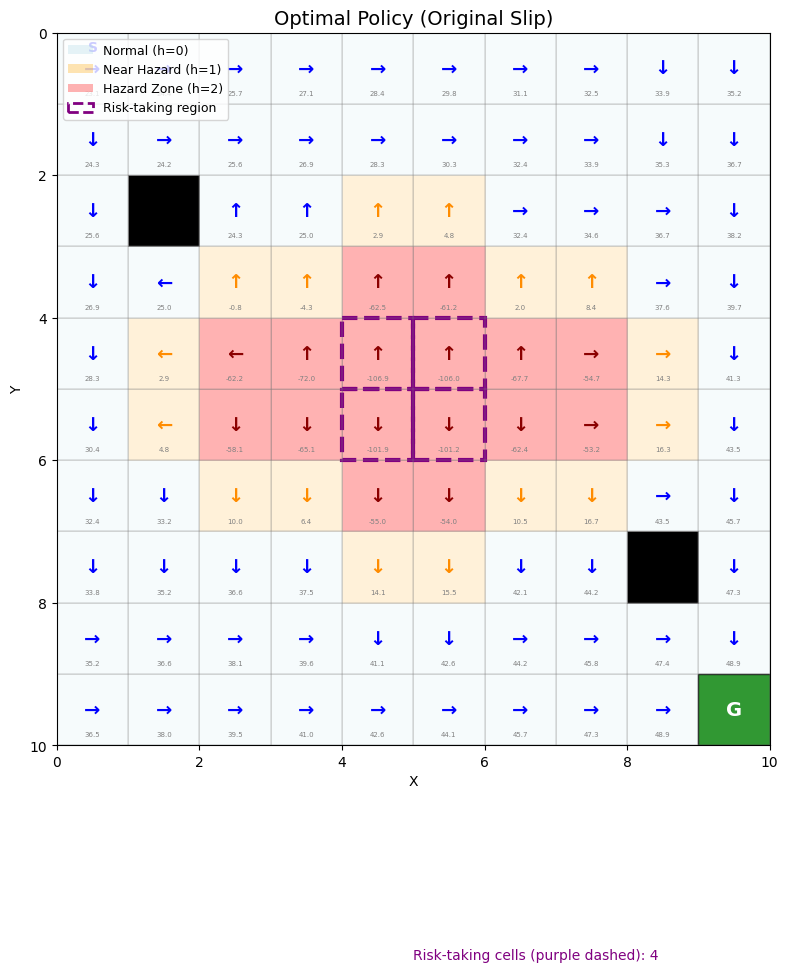

Saved: risk_policy_orig.png

--- Policy Iteration ---
Converged in 7 iterations
Runtime: 8.1639 seconds
Peak memory: 20.51 KB

(b) RISK-TAKING REGION ANALYSIS

  Risk-Taking Cells (near/in hazard, action moves into hazard):
    (4, 4) h=2 -> action: Up
    (4, 5) h=2 -> action: Down
    (5, 4) h=2 -> action: Up
    (5, 5) h=2 -> action: Down

  Risk-Avoiding Cells (near hazard, action moves away):
    (1, 4) h=1 -> action: Left
    (1, 5) h=1 -> action: Left
    (2, 3) h=1 -> action: Up
    (2, 6) h=1 -> action: Down
    (3, 3) h=1 -> action: Up
    (3, 6) h=1 -> action: Down
    (4, 2) h=1 -> action: Up
    (4, 7) h=1 -> action: Down
    (5, 2) h=1 -> action: Up
    (5, 7) h=1 -> action: Down

  Summary: 4 risk-taking, 16 risk-avoiding near hazards

  Path Statistics (10,000 simulations from start):
    Success rate: 0.9945
    Failure rate: 0.0055
    Avg reward: 29.72 ± 18.24
    Avg path length: 18.9
    Avg hazard cell visits: 0.1

(c) INCREASED SLIP PROBABILITY

--- Config 1: Mod

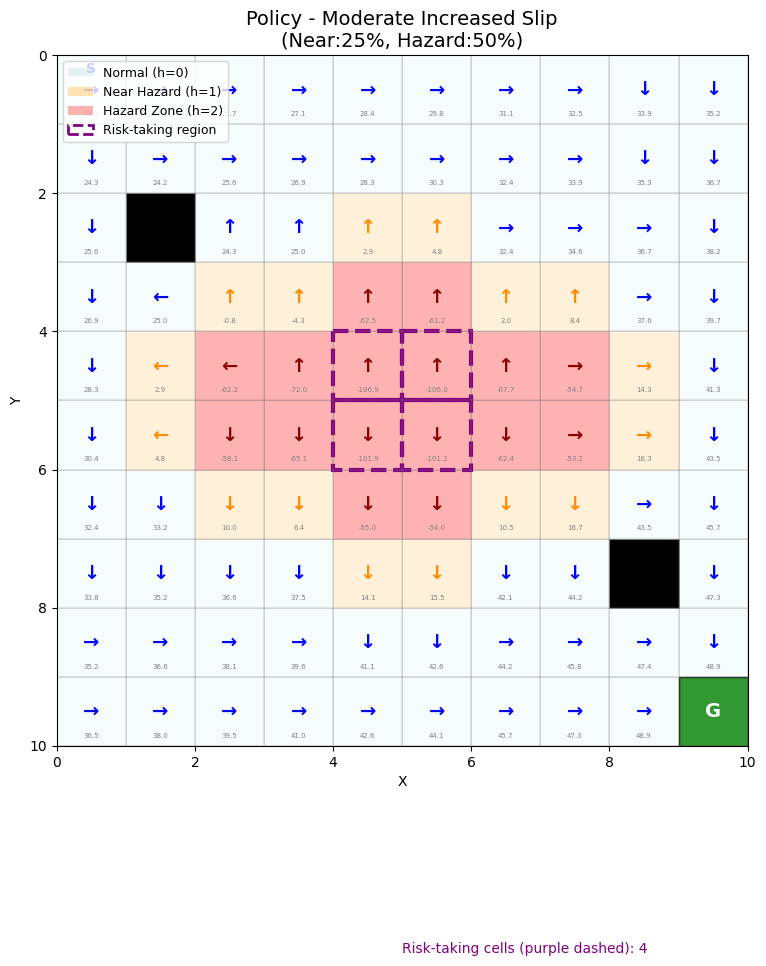

Saved: risk_policy_moderate.png


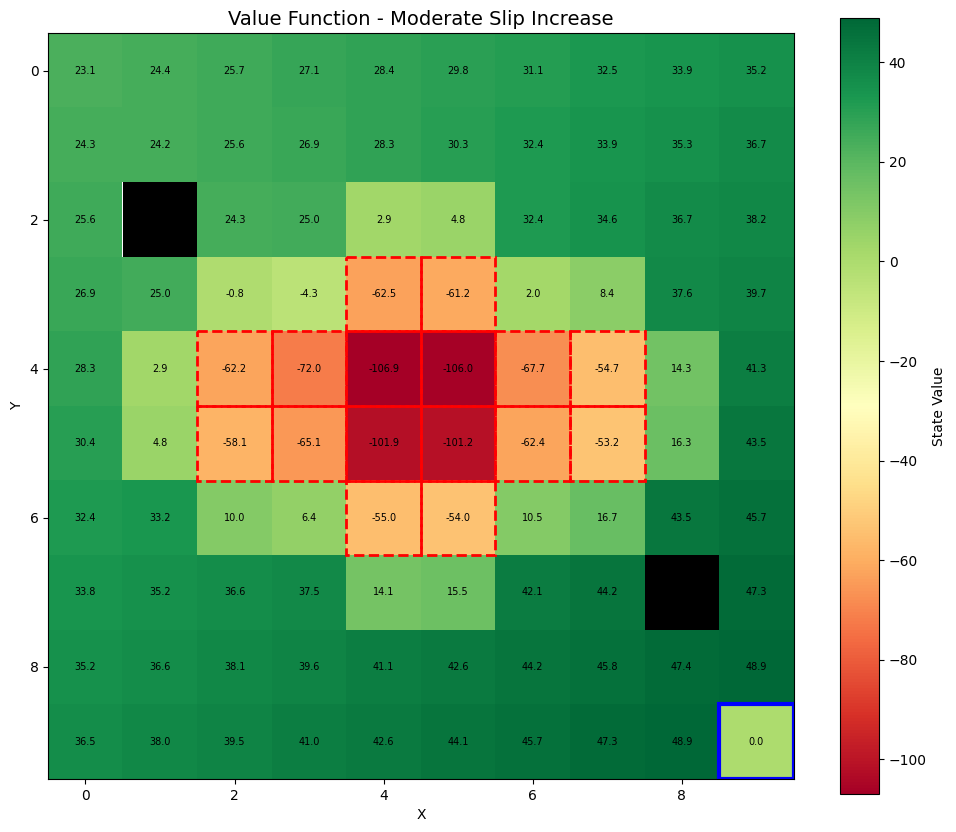

Saved: risk_value_moderate.png

--- Config 2: High Increase ---
Risk-Sensitive Robot Navigation MDP
Grid Size: 10x10
Hazard Zones (h=2): [(2, 4), (2, 5), (3, 4), (3, 5), (4, 3), (4, 4), (4, 5), (4, 6), (5, 3), (5, 4), (5, 5), (5, 6), (6, 4), (6, 5), (7, 4), (7, 5)]
Near-Hazard Zones (h=1): [(1, 4), (1, 5), (2, 3), (2, 6), (3, 3), (3, 6), (4, 2), (4, 7), (5, 2), (5, 7), (6, 3), (6, 6), (7, 3), (7, 6), (8, 4), (8, 5)]
Obstacles: [(1, 2), (8, 7)]
Goal: (9, 9)
Start: (0, 0)
States: 98
Slip probs - Normal: 0.0, Near: 0.1, Hazard: 0.3

Updated slip probabilities:
  Near hazard: 0.1 -> 0.4
  In hazard: 0.3 -> 0.7
  Near hazard success prob: 0.5
  In hazard success prob: 0.20000000000000007

--- Value Iteration ---
Converged in 36 iterations
Runtime: 0.1408 seconds
Peak memory: 18.34 KB

--- Policy Iteration ---
Converged in 7 iterations
Runtime: 5.1087 seconds
Peak memory: 19.24 KB


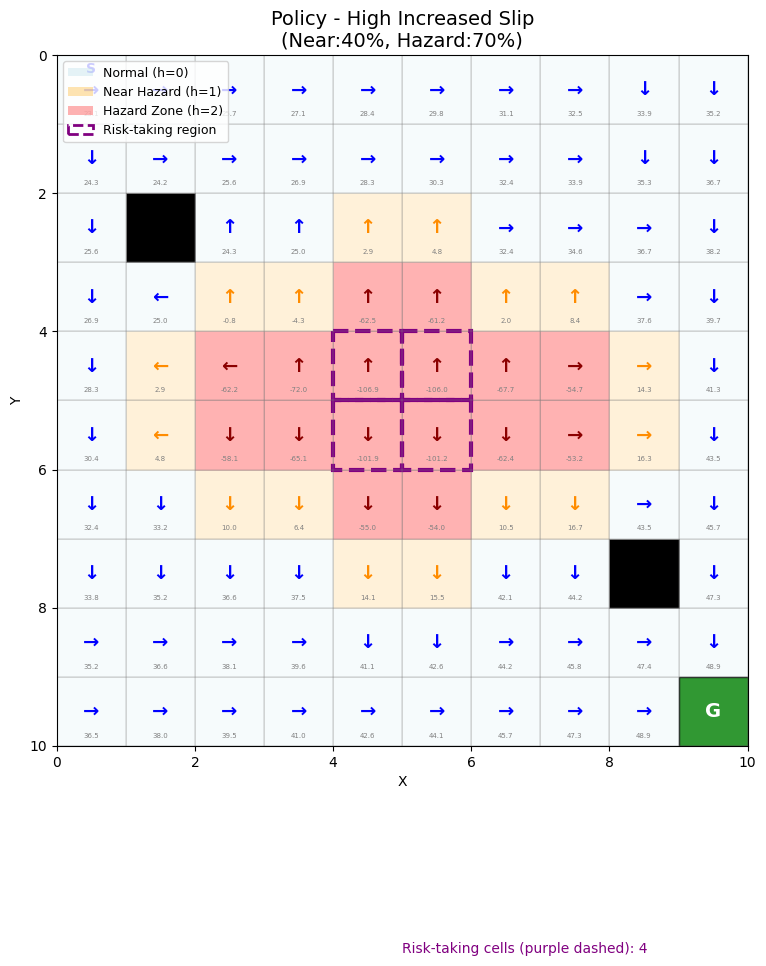

Saved: risk_policy_high.png


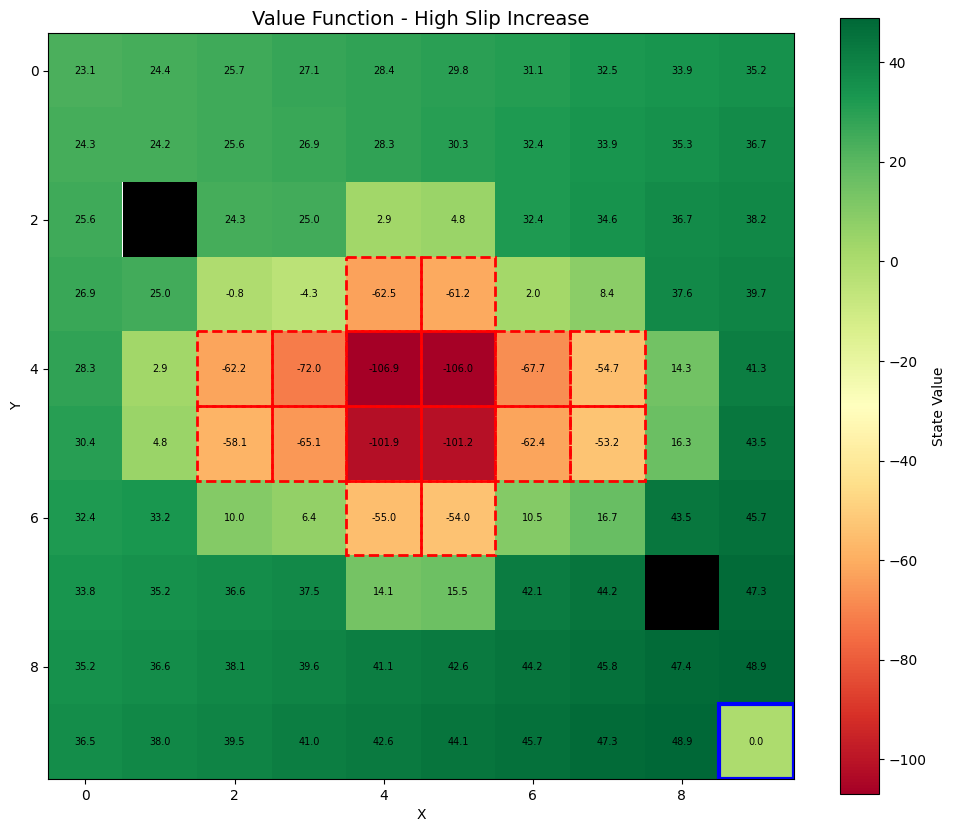

Saved: risk_value_high.png

(d) POLICY COMPARISON

Policy - Original (Near:10%, Hazard:30%):
--------------------------------------------------
y\x| 0 1 2 3 4 5 6 7 8 9
--------------------------------------------------
 0 | R R R R R R R R D D 
 1 | D R R R R R R R D D 
 2 | D X U U U U R R R D 
 3 | D L U U U U U U R D 
 4 | D L L U U U U R R D 
 5 | D L D D D D D R R D 
 6 | D D D D D D D D R D 
 7 | D D D D D D D D X D 
 8 | R R R R D D R R R D 
 9 | R R R R R R R R R G 
--------------------------------------------------

Policy - Moderate (Near:25%, Hazard:50%):
--------------------------------------------------
y\x| 0 1 2 3 4 5 6 7 8 9
--------------------------------------------------
 0 | R R R R R R R R D D 
 1 | D R R R R R R R D D 
 2 | D X U U U U R R R D 
 3 | D L U U U U U U R D 
 4 | D L L U U U U R R D 
 5 | D L D D D D D R R D 
 6 | D D D D D D D D R D 
 7 | D D D D D D D D X D 
 8 | R R R R D D R R R D 
 9 | R R R R R R R R R G 
---------------------------------------

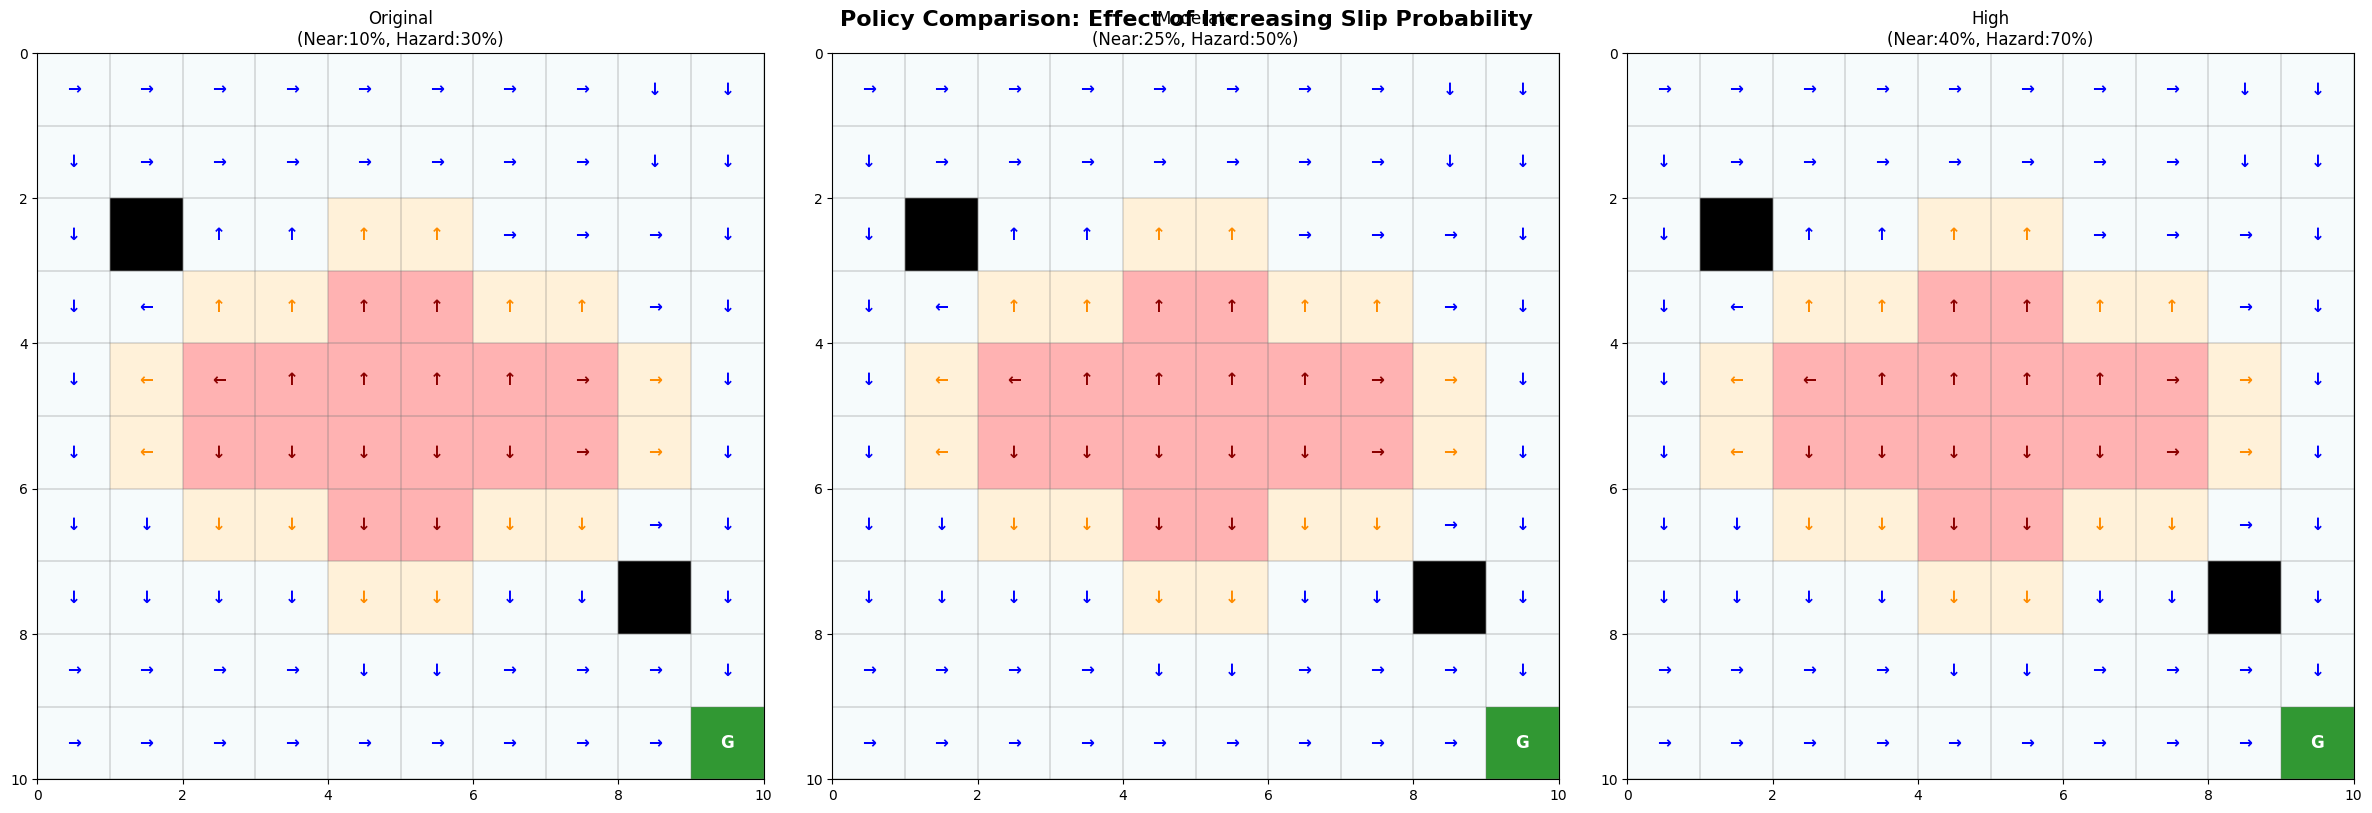

Saved: risk_policy_comparison.png


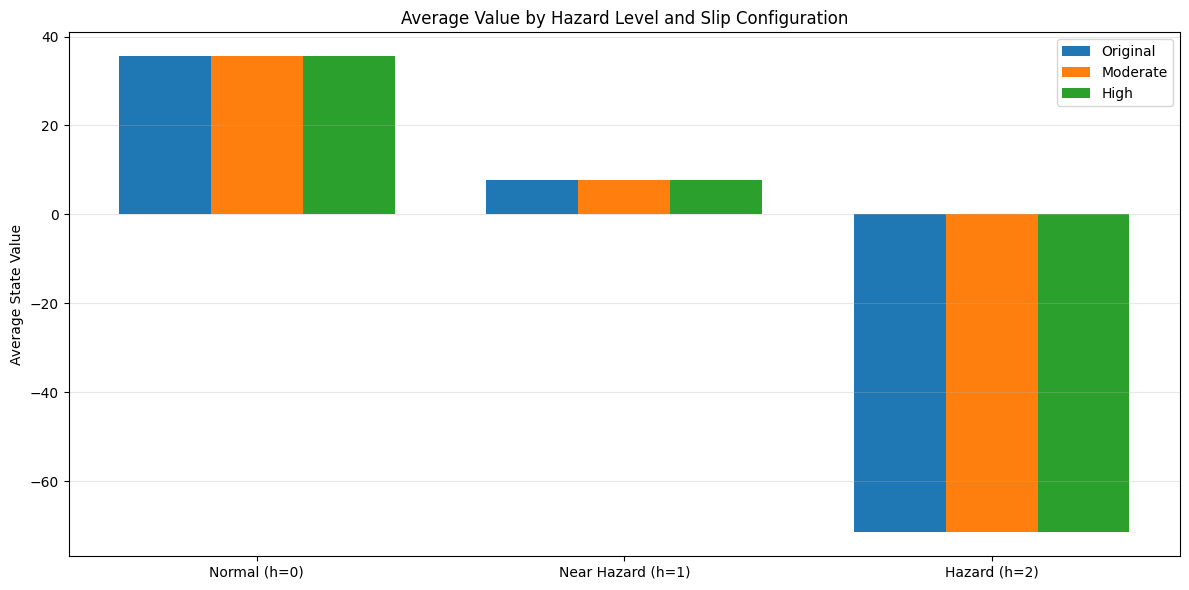

Saved: risk_value_comparison.png

(e) WHY SHORTEST-PATH INTUITION FAILS

    WHY SHORTEST-PATH INTUITION FAILS IN RISK-SENSITIVE NAVIGATION
    
    1. DETERMINISTIC vs STOCHASTIC SHORTEST PATH:
       In a deterministic environment, the shortest path from Start (0,0) 
       to Goal (9,9) is the Manhattan path of length 18. This path would 
       cut diagonally through the grid, passing through the hazard zone.
       
       In our stochastic environment, each step in/near the hazard zone 
       carries a probability of catastrophic failure (-200 reward). The 
       expected cost of the "short" path through hazards can be:
       
       E[short path] = (1-p_fail)^n × (reward_goal - n) + 
                        [1-(1-p_fail)^n] × (-200)
       
       where n is the number of hazard cells traversed and p_fail is the 
       per-step catastrophe probability.
    
    2. NUMERICAL EXAMPLE:
       Short path through 6 hazard cells (h=2, p_catastrophe=0.30):
       P(survive all 6) =

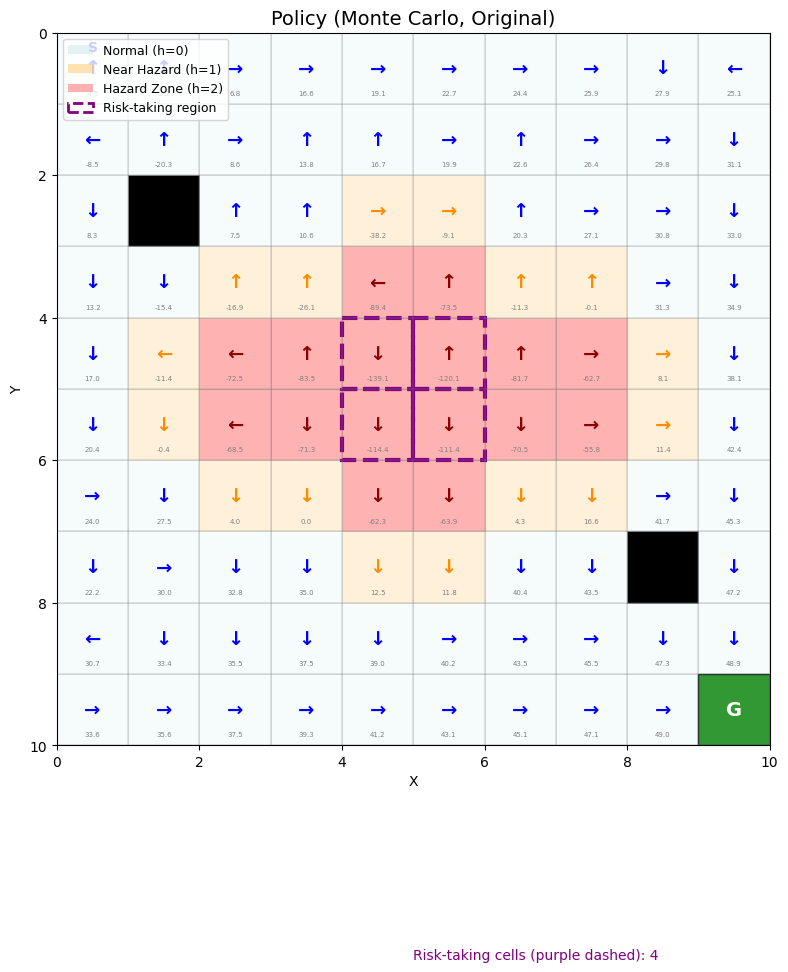

Saved: risk_policy_mc.png

--- MC: Moderate Slip ---
  MC Episode 25000/100000, Avg V: -1.3364
  MC Episode 50000/100000, Avg V: 1.3243
  MC Episode 75000/100000, Avg V: 2.8070
  MC Episode 100000/100000, Avg V: 3.9136

--- Monte Carlo ---
Episodes: 100000
Runtime: 308.2696 seconds
Peak memory: 101.30 KB

--- MC: High Slip ---
  MC Episode 25000/100000, Avg V: -1.0144
  MC Episode 50000/100000, Avg V: 1.6575
  MC Episode 75000/100000, Avg V: 2.8583
  MC Episode 100000/100000, Avg V: 3.4559

--- Monte Carlo ---
Episodes: 100000
Runtime: 313.3581 seconds
Peak memory: 81.00 KB

    ┌──────────────────────────┬──────────────┬──────────────┬──────────────┐
    │ Metric                   │ Value Iter.  │ Policy Iter. │ Monte Carlo  │
    ├──────────────────────────┼──────────────┼──────────────┼──────────────┤
    │ Iterations/Episodes      │           36 │            7 │       100000 │
    │ Runtime (seconds)        │       0.3219 │       8.1639 │     301.6094 │
    │ Peak Memory (KB)      

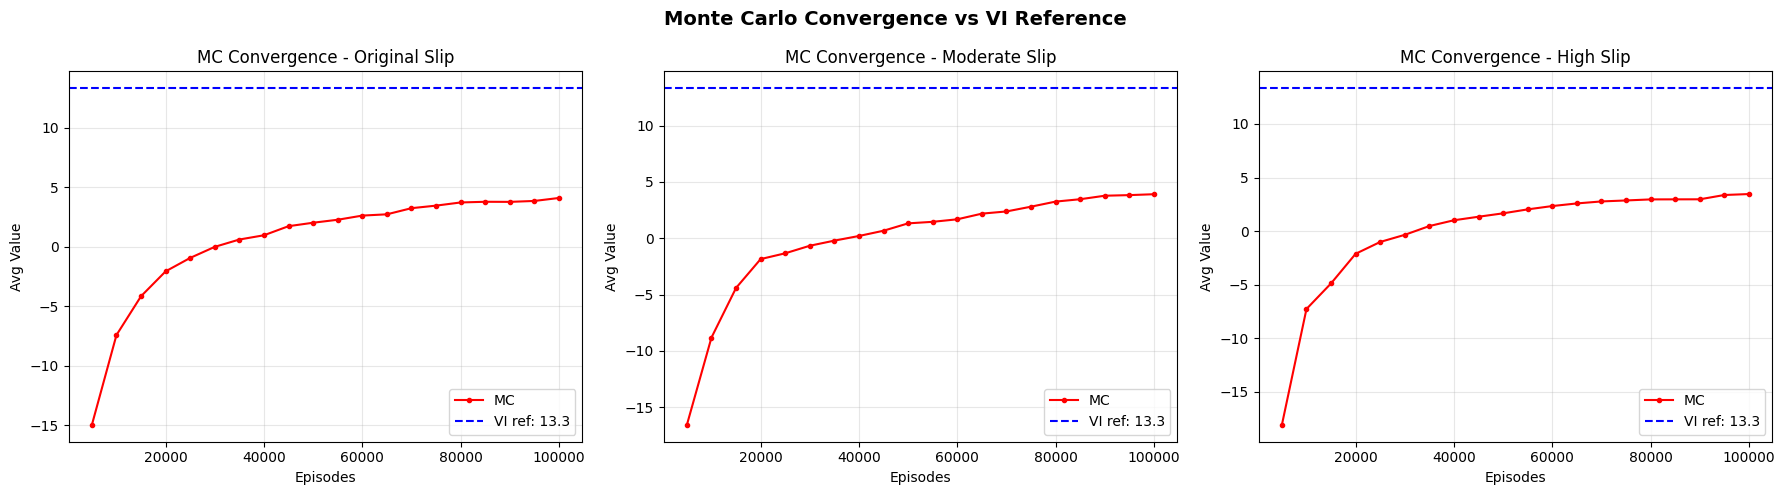

Saved: risk_mc_convergence.png


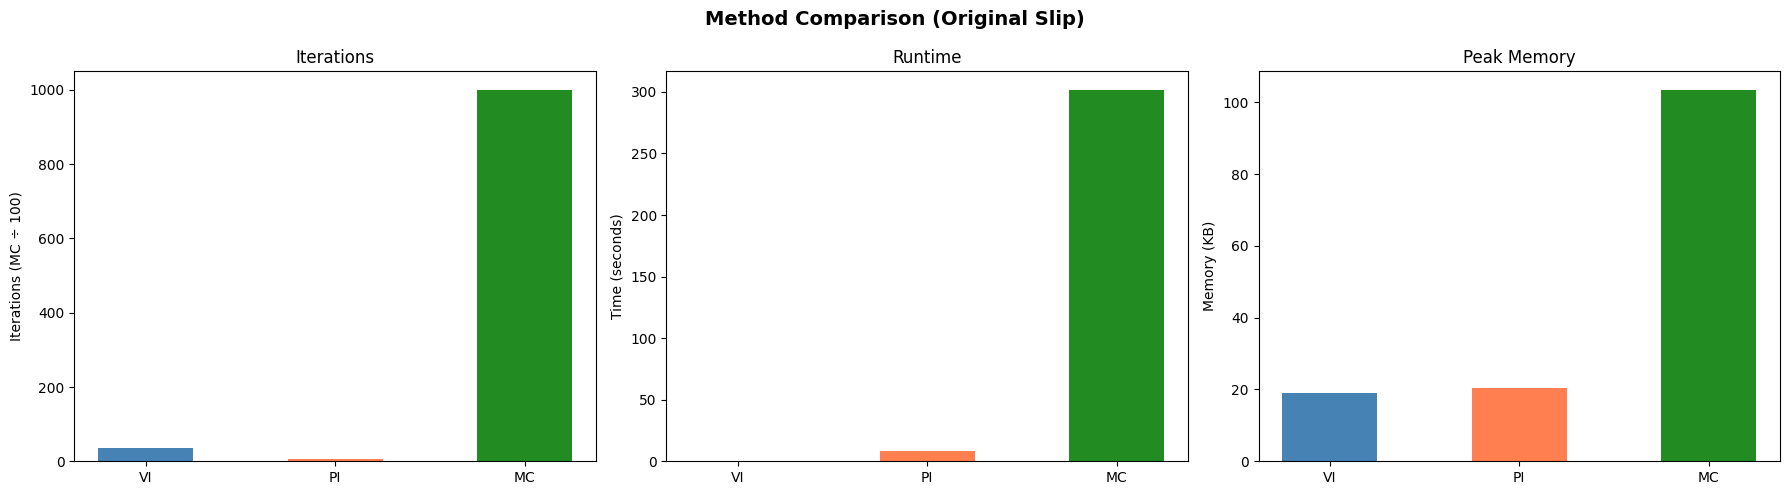

Saved: risk_method_comparison.png

  MC Performance Across Slip Configurations:
  Config               |    Success |   Avg Reward |  Hazard Visits
-----------------------------------------------------------------
  Original             |     0.4785 |       -58.06 |            0.0
  Moderate             |     0.0258 |       -97.73 |            0.0
  High                 |     0.0119 |       -99.01 |            0.0

ALL GENERATED FILES

    1.  risk_grid.png                - Environment with hazard zones
    2.  risk_conv_vi_orig.png        - VI convergence (original slip)
    3.  risk_value_orig.png          - Value function (original)
    4.  risk_policy_orig.png         - Optimal policy with risk regions marked
    5.  risk_policy_moderate.png     - Policy with moderate increased slip
    6.  risk_value_moderate.png      - Value function (moderate slip)
    7.  risk_policy_high.png         - Policy with high increased slip
    8.  risk_value_high.png          - Value function (high s

In [ ]:
import numpy as np
import random
import time
import tracemalloc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict
import copy

# ============================================================================
# ENVIRONMENT SETUP
# ============================================================================

class RiskSensitiveRobotMDP:
    """
    Risk-Sensitive Robot Navigation MDP.
    State: (x, y, h) where h indicates hazard proximity level
    h = 0: normal region
    h = 1: near hazard (adjacent to hazard zone)
    h = 2: in hazard zone (high risk)
    """

    def __init__(self, grid_size=10, seed=42):
        self.grid_size = grid_size
        self.hazard_levels = [0, 1, 2]  # 0=normal, 1=near hazard, 2=in hazard
        self.hazard_names = ['Normal', 'Near Hazard', 'In Hazard']

        # Actions: Up, Down, Left, Right
        self.actions = [0, 1, 2, 3]
        self.action_names = ['Up', 'Down', 'Left', 'Right']

        # Direction vectors
        self.dx = [0, 0, -1, 1]
        self.dy = [-1, 1, 0, 0]

        # Rewards
        self.step_reward = -1
        self.goal_reward = 50
        self.catastrophe_reward = -200

        # Slip probabilities (configurable)
        self.slip_probs = {
            0: 0.0,    # Normal: no slip
            1: 0.1,    # Near hazard: 10% slip
            2: 0.3,    # In hazard: 30% slip
        }

        # Success probabilities for intended action
        self.success_probs = {
            0: 0.95,   # Normal: 95% success, 5% perpendicular slip
            1: 0.80,   # Near hazard: 80% success, 10% each side, 10% catastrophe
            2: 0.60,   # In hazard: 60% success, 10% slip, 30% catastrophe
        }

        random.seed(seed)
        np.random.seed(seed)

        # Define hazard zones (cliff/fragile terrain regions)
        self.hazard_zones = set()      # h=2 cells
        self.near_hazard_zones = set() # h=1 cells
        self.obstacles = set()

        self._setup_environment()

        # Goal and start
        self.goal = (9, 9)
        self.start = (0, 0)

        # Terminal state
        self.terminal_state = 'TERMINAL'
        self.catastrophe_state = 'CATASTROPHE'

        # Build state space
        self.states = []
        for x in range(grid_size):
            for y in range(grid_size):
                if (x, y) not in self.obstacles:
                    h = self._get_hazard_level(x, y)
                    self.states.append((x, y, h))

        self.n_states = len(self.states)
        self.n_actions = len(self.actions)

        print("=" * 60)
        print("Risk-Sensitive Robot Navigation MDP")
        print("=" * 60)
        print(f"Grid Size: {grid_size}x{grid_size}")
        print(f"Hazard Zones (h=2): {sorted(self.hazard_zones)}")
        print(f"Near-Hazard Zones (h=1): {sorted(self.near_hazard_zones)}")
        print(f"Obstacles: {sorted(self.obstacles)}")
        print(f"Goal: {self.goal}")
        print(f"Start: {self.start}")
        print(f"States: {self.n_states}")
        print(f"Slip probs - Normal: {self.slip_probs[0]}, "
              f"Near: {self.slip_probs[1]}, Hazard: {self.slip_probs[2]}")
        print("=" * 60)

        self._build_transitions()

    def _setup_environment(self):
        """
        Create a map with:
        - A hazardous cliff/ravine region in the middle
        - A short path through the hazard zone
        - A longer safe path around
        """
        gs = self.grid_size

        # Hazard zone: a "cliff" region running through the middle
        # This creates a diagonal hazard strip that the robot must navigate around
        # or risk crossing

        # Hazard zone (h=2) - the cliff/ravine
        for i in range(2, 8):
            self.hazard_zones.add((i, 4))
            self.hazard_zones.add((i, 5))

        # Additional hazard patches
        self.hazard_zones.add((4, 3))
        self.hazard_zones.add((5, 3))
        self.hazard_zones.add((4, 6))
        self.hazard_zones.add((5, 6))

        # Near-hazard zones (h=1) - cells adjacent to hazard
        for (hx, hy) in list(self.hazard_zones):
            for dx, dy in [(0, 1), (0, -1), (1, 0), (-1, 0)]:
                nx, ny = hx + dx, hy + dy
                if (0 <= nx < gs and 0 <= ny < gs and
                    (nx, ny) not in self.hazard_zones):
                    self.near_hazard_zones.add((nx, ny))

        # A few obstacles (walls)
        self.obstacles = {(1, 2), (8, 7)}

        # Remove obstacles from hazard zones
        self.hazard_zones -= self.obstacles
        self.near_hazard_zones -= self.obstacles

    def _get_hazard_level(self, x, y):
        """Get hazard level for a cell."""
        if (x, y) in self.hazard_zones:
            return 2
        elif (x, y) in self.near_hazard_zones:
            return 1
        else:
            return 0

    def _build_transitions(self):
        """
        Build transition model.

        In normal regions (h=0):
            - Intended direction: 95% success
            - Perpendicular slip: 2.5% each side
            - No catastrophe

        Near hazard (h=1):
            - Intended direction: 80% success
            - Perpendicular slip: 5% each side
            - Catastrophe (slip into hazard): 10%

        In hazard zone (h=2):
            - Intended direction: 60% success
            - Perpendicular slip: 5% each side
            - Catastrophe: 30%
        """
        self.transitions = {}

        for s in self.states:
            x, y, h = s
            self.transitions[s] = {}

            if (x, y) == self.goal:
                for a in self.actions:
                    self.transitions[s][a] = [(1.0, self.terminal_state, 0, True)]
                continue

            for a in self.actions:
                outcomes = []

                if h == 0:  # Normal region
                    # 95% intended, 2.5% each perpendicular
                    p_success = 0.95
                    p_side = 0.025
                    p_catastrophe = 0.0
                elif h == 1:  # Near hazard
                    p_success = 0.80
                    p_side = 0.05
                    p_catastrophe = 0.10
                else:  # h == 2, In hazard
                    p_success = 0.60
                    p_side = 0.05
                    p_catastrophe = 0.30

                # Intended direction
                nx, ny = x + self.dx[a], y + self.dy[a]
                outcomes.append((p_success, nx, ny, 'move'))

                # Perpendicular slips
                if a in [0, 1]:  # Up/Down -> slip Left/Right
                    perp = [2, 3]
                else:  # Left/Right -> slip Up/Down
                    perp = [0, 1]

                for p_a in perp:
                    snx, sny = x + self.dx[p_a], y + self.dy[p_a]
                    outcomes.append((p_side, snx, sny, 'move'))

                # Catastrophe
                if p_catastrophe > 0:
                    outcomes.append((p_catastrophe, None, None, 'catastrophe'))

                # Process outcomes
                transition_list = []
                for outcome in outcomes:
                    if outcome[3] == 'catastrophe':
                        transition_list.append((outcome[0], self.terminal_state,
                                               self.step_reward + self.catastrophe_reward, True))
                    else:
                        prob, nx, ny = outcome[0], outcome[1], outcome[2]

                        if not (0 <= nx < self.grid_size and 0 <= ny < self.grid_size):
                            # Hit boundary: stay in place
                            new_h = self._get_hazard_level(x, y)
                            transition_list.append((prob, (x, y, new_h), self.step_reward, False))
                        elif (nx, ny) in self.obstacles:
                            # Hit obstacle: stay in place
                            new_h = self._get_hazard_level(x, y)
                            transition_list.append((prob, (x, y, new_h), self.step_reward, False))
                        elif (nx, ny) == self.goal:
                            transition_list.append((prob, self.terminal_state,
                                                   self.step_reward + self.goal_reward, True))
                        else:
                            new_h = self._get_hazard_level(nx, ny)
                            transition_list.append((prob, (nx, ny, new_h), self.step_reward, False))

                # Merge transitions with same next state
                merged = {}
                for prob, ns, r, d in transition_list:
                    key = (ns, r, d)
                    merged[key] = merged.get(key, 0) + prob

                self.transitions[s][a] = [(p, ns, r, d) for (ns, r, d), p in merged.items()]

    def get_transitions(self, state, action):
        if state == self.terminal_state:
            return [(1.0, self.terminal_state, 0, True)]
        return self.transitions[state][action]

    def update_slip_probabilities(self, near_hazard_catastrophe, in_hazard_catastrophe):
        """Update slip probabilities and rebuild transitions."""
        old_near = self.slip_probs[1]
        old_hazard = self.slip_probs[2]

        self.slip_probs[1] = near_hazard_catastrophe
        self.slip_probs[2] = in_hazard_catastrophe

        print(f"\nUpdated slip probabilities:")
        print(f"  Near hazard: {old_near} -> {near_hazard_catastrophe}")
        print(f"  In hazard: {old_hazard} -> {in_hazard_catastrophe}")

        # Rebuild with new probabilities
        # We need to update the success probabilities too
        # Near hazard: success + 2*side + catastrophe = 1
        # side stays at 0.05
        self.success_probs[1] = 1.0 - 2 * 0.05 - near_hazard_catastrophe
        self.success_probs[2] = 1.0 - 2 * 0.05 - in_hazard_catastrophe

        print(f"  Near hazard success prob: {self.success_probs[1]}")
        print(f"  In hazard success prob: {self.success_probs[2]}")

        self._build_transitions()


# ============================================================================
# VALUE ITERATION
# ============================================================================

def value_iteration_risk(mdp, gamma=0.99, theta=1e-6, max_iterations=2000):
    """Value Iteration for risk-sensitive MDP."""
    tracemalloc.start()
    start_time = time.time()

    V = {s: 0.0 for s in mdp.states}
    V[mdp.terminal_state] = 0.0

    deltas = []

    for iteration in range(1, max_iterations + 1):
        delta = 0
        V_new = {}

        for s in mdp.states:
            x, y, h = s
            if (x, y) == mdp.goal:
                V_new[s] = 0.0
                continue

            action_values = []
            for a in mdp.actions:
                q_val = 0.0
                for prob, ns, reward, done in mdp.get_transitions(s, a):
                    if done:
                        q_val += prob * reward
                    else:
                        q_val += prob * (reward + gamma * V.get(ns, 0))
                action_values.append(q_val)

            V_new[s] = max(action_values)
            delta = max(delta, abs(V_new[s] - V[s]))

        V = V_new
        V[mdp.terminal_state] = 0.0
        deltas.append(delta)

        if delta < theta:
            break

    # Extract policy
    policy = {}
    for s in mdp.states:
        x, y, h = s
        if (x, y) == mdp.goal:
            policy[s] = 0
            continue

        action_values = []
        for a in mdp.actions:
            q_val = 0.0
            for prob, ns, reward, done in mdp.get_transitions(s, a):
                if done:
                    q_val += prob * reward
                else:
                    q_val += prob * (reward + gamma * V.get(ns, 0))
            action_values.append(q_val)
        policy[s] = int(np.argmax(action_values))

    end_time = time.time()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    runtime = end_time - start_time
    memory_peak = peak / 1024

    print(f"\n--- Value Iteration ---")
    print(f"Converged in {iteration} iterations")
    print(f"Runtime: {runtime:.4f} seconds")
    print(f"Peak memory: {memory_peak:.2f} KB")

    return V, policy, iteration, runtime, memory_peak, deltas


# ============================================================================
# POLICY ITERATION
# ============================================================================

def policy_evaluation_risk(mdp, policy, gamma=0.99, theta=1e-6, max_iterations=2000):
    """Policy evaluation for risk-sensitive MDP."""
    V = {s: 0.0 for s in mdp.states}
    V[mdp.terminal_state] = 0.0

    for _ in range(max_iterations):
        delta = 0
        for s in mdp.states:
            x, y, h = s
            if (x, y) == mdp.goal:
                continue

            a = policy[s]
            v_new = 0.0
            for prob, ns, reward, done in mdp.get_transitions(s, a):
                if done:
                    v_new += prob * reward
                else:
                    v_new += prob * (reward + gamma * V.get(ns, 0))

            delta = max(delta, abs(v_new - V[s]))
            V[s] = v_new

        if delta < theta:
            break

    return V


def policy_iteration_risk(mdp, gamma=0.99, max_iterations=100):
    """Policy Iteration for risk-sensitive MDP."""
    tracemalloc.start()
    start_time = time.time()

    # Initialize policy
    policy = {s: random.choice(mdp.actions) for s in mdp.states}

    iteration = 0
    for iteration in range(1, max_iterations + 1):
        V = policy_evaluation_risk(mdp, policy, gamma)

        policy_stable = True
        for s in mdp.states:
            x, y, h = s
            if (x, y) == mdp.goal:
                continue

            old_action = policy[s]
            action_values = []
            for a in mdp.actions:
                q_val = 0.0
                for prob, ns, reward, done in mdp.get_transitions(s, a):
                    if done:
                        q_val += prob * reward
                    else:
                        q_val += prob * (reward + gamma * V.get(ns, 0))
                action_values.append(q_val)

            policy[s] = int(np.argmax(action_values))
            if old_action != policy[s]:
                policy_stable = False

        if policy_stable:
            break

    end_time = time.time()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    runtime = end_time - start_time
    memory_peak = peak / 1024

    print(f"\n--- Policy Iteration ---")
    print(f"Converged in {iteration} iterations")
    print(f"Runtime: {runtime:.4f} seconds")
    print(f"Peak memory: {memory_peak:.2f} KB")

    return V, policy, iteration, runtime, memory_peak


# ============================================================================
# MONTE CARLO METHOD
# ============================================================================

def monte_carlo_risk(mdp, gamma=0.99, num_episodes=100000, epsilon=0.15,
                     record_interval=5000):
    """On-policy first-visit MC with epsilon-greedy."""
    tracemalloc.start()
    start_time = time.time()

    Q = defaultdict(lambda: np.zeros(mdp.n_actions))
    returns_count = defaultdict(lambda: np.zeros(mdp.n_actions))
    returns_sum = defaultdict(lambda: np.zeros(mdp.n_actions))

    value_history = []

    for ep in range(1, num_episodes + 1):
        # Random start
        valid_starts = [s for s in mdp.states if (s[0], s[1]) != mdp.goal]
        state = random.choice(valid_starts)
        episode = []

        for step in range(300):
            if state == mdp.terminal_state:
                break

            x, y, h = state
            if (x, y) == mdp.goal:
                break

            # Epsilon-greedy
            if random.random() < epsilon:
                action = random.choice(mdp.actions)
            else:
                action = int(np.argmax(Q[state]))

            transitions = mdp.get_transitions(state, action)
            probs = [t[0] for t in transitions]
            idx = np.random.choice(len(transitions), p=probs)
            prob, next_state, reward, done = transitions[idx]

            episode.append((state, action, reward))

            if done:
                break
            state = next_state

        # First-visit MC
        G = 0
        visited = set()
        for t in range(len(episode) - 1, -1, -1):
            s_t, a_t, r_t = episode[t]
            G = gamma * G + r_t

            sa = (s_t, a_t)
            if sa not in visited:
                visited.add(sa)
                returns_sum[s_t][a_t] += G
                returns_count[s_t][a_t] += 1
                Q[s_t][a_t] = returns_sum[s_t][a_t] / returns_count[s_t][a_t]

        if ep % record_interval == 0:
            V_temp = {}
            for s in mdp.states:
                if s in Q and np.any(returns_count[s] > 0):
                    V_temp[s] = np.max(Q[s])
                else:
                    V_temp[s] = 0.0
            valid_v = [V_temp[s] for s in mdp.states if (s[0], s[1]) != mdp.goal]
            avg_v = np.mean(valid_v) if valid_v else 0
            value_history.append((ep, avg_v))
            if ep % 25000 == 0:
                print(f"  MC Episode {ep}/{num_episodes}, Avg V: {avg_v:.4f}")

    # Extract policy and V
    policy = {}
    V = {}
    for s in mdp.states:
        x, y, h = s
        if (x, y) == mdp.goal:
            policy[s] = 0
            V[s] = 0.0
        elif s in Q and np.any(returns_count[s] > 0):
            policy[s] = int(np.argmax(Q[s]))
            V[s] = np.max(Q[s])
        else:
            policy[s] = random.choice(mdp.actions)
            V[s] = 0.0

    end_time = time.time()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    runtime = end_time - start_time
    memory_peak = peak / 1024

    print(f"\n--- Monte Carlo ---")
    print(f"Episodes: {num_episodes}")
    print(f"Runtime: {runtime:.4f} seconds")
    print(f"Peak memory: {memory_peak:.2f} KB")

    return V, policy, num_episodes, runtime, memory_peak, value_history


# ============================================================================
# VISUALIZATION FUNCTIONS
# ============================================================================

def visualize_risk_grid(mdp, title="Risk Environment", filename="risk_grid.png"):
    """Visualize the grid with hazard zones."""
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))

    for x in range(mdp.grid_size + 1):
        ax.axhline(y=x, color='gray', linewidth=0.5)
        ax.axvline(x=x, color='gray', linewidth=0.5)

    # Color cells by hazard level
    for x in range(mdp.grid_size):
        for y in range(mdp.grid_size):
            if (x, y) in mdp.obstacles:
                color = 'black'
                alpha = 1.0
            elif (x, y) in mdp.hazard_zones:
                color = 'red'
                alpha = 0.5
            elif (x, y) in mdp.near_hazard_zones:
                color = 'orange'
                alpha = 0.3
            else:
                color = 'white'
                alpha = 0.1

            rect = plt.Rectangle((x, y), 1, 1, facecolor=color,
                                edgecolor='gray', alpha=alpha)
            ax.add_patch(rect)

    # Goal
    gx, gy = mdp.goal
    rect = plt.Rectangle((gx, gy), 1, 1, facecolor='green', edgecolor='black', alpha=0.8)
    ax.add_patch(rect)
    ax.text(gx + 0.5, gy + 0.5, 'G', ha='center', va='center', fontsize=14,
            fontweight='bold', color='white')

    # Start
    sx, sy = mdp.start
    rect = plt.Rectangle((sx, sy), 1, 1, facecolor='blue', edgecolor='black', alpha=0.5)
    ax.add_patch(rect)
    ax.text(sx + 0.5, sy + 0.5, 'S', ha='center', va='center', fontsize=14,
            fontweight='bold', color='white')

    # Hazard level labels
    for x in range(mdp.grid_size):
        for y in range(mdp.grid_size):
            if (x, y) not in mdp.obstacles and (x, y) != mdp.goal and (x, y) != mdp.start:
                h = mdp._get_hazard_level(x, y)
                if h > 0:
                    ax.text(x + 0.5, y + 0.5, f'h={h}', ha='center', va='center',
                           fontsize=8, color='darkred')

    legend_elements = [
        mpatches.Patch(facecolor='white', edgecolor='gray', label='Normal (h=0)'),
        mpatches.Patch(facecolor='orange', alpha=0.5, label='Near Hazard (h=1)'),
        mpatches.Patch(facecolor='red', alpha=0.5, label='Hazard Zone (h=2)'),
        mpatches.Patch(facecolor='black', label='Obstacle'),
        mpatches.Patch(facecolor='green', alpha=0.8, label='Goal'),
        mpatches.Patch(facecolor='blue', alpha=0.5, label='Start'),
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=10)

    ax.set_xlim(0, mdp.grid_size)
    ax.set_ylim(0, mdp.grid_size)
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")


def visualize_risk_policy(mdp, policy, V=None, title="Policy", filename="risk_policy.png",
                           show_risk_regions=True):
    """Visualize policy with hazard zones highlighted."""
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))

    arrow_symbols = {0: '↑', 1: '↓', 2: '←', 3: '→'}

    # Color background by hazard level
    for x in range(mdp.grid_size):
        for y in range(mdp.grid_size):
            if (x, y) in mdp.obstacles:
                color = 'black'
                alpha = 1.0
            elif (x, y) in mdp.hazard_zones:
                color = 'red'
                alpha = 0.3
            elif (x, y) in mdp.near_hazard_zones:
                color = 'orange'
                alpha = 0.15
            else:
                color = 'lightblue'
                alpha = 0.1

            rect = plt.Rectangle((x, y), 1, 1, facecolor=color,
                                edgecolor='gray', alpha=alpha, linewidth=0.5)
            ax.add_patch(rect)

    # Grid lines
    for x in range(mdp.grid_size + 1):
        ax.axhline(y=x, color='gray', linewidth=0.3)
        ax.axvline(x=x, color='gray', linewidth=0.3)

    # Goal
    gx, gy = mdp.goal
    rect = plt.Rectangle((gx, gy), 1, 1, facecolor='green', edgecolor='black', alpha=0.8)
    ax.add_patch(rect)
    ax.text(gx + 0.5, gy + 0.5, 'G', ha='center', va='center', fontsize=14,
            fontweight='bold', color='white')

    # Start
    sx, sy = mdp.start
    ax.text(sx + 0.5, sy + 0.2, 'S', ha='center', va='center', fontsize=10,
            fontweight='bold', color='blue')

    # Policy arrows
    for s in mdp.states:
        x, y, h = s
        if (x, y) == mdp.goal or (x, y) in mdp.obstacles:
            continue

        a = policy[s]

        # Color based on hazard level
        if h == 2:
            color = 'darkred'
        elif h == 1:
            color = 'darkorange'
        else:
            color = 'blue'

        ax.text(x + 0.5, y + 0.5, arrow_symbols[a], ha='center', va='center',
               fontsize=14, color=color, fontweight='bold')

        # Show value if provided
        if V is not None:
            ax.text(x + 0.5, y + 0.85, f'{V.get(s,0):.1f}', ha='center', va='center',
                   fontsize=5, color='gray')

    # Identify and highlight risk-taking regions
    if show_risk_regions:
        risk_taking = []
        for s in mdp.states:
            x, y, h = s
            if h >= 1 and (x, y) != mdp.goal:
                a = policy[s]
                # Check if action moves toward/into hazard
                nx, ny = x + mdp.dx[a], y + mdp.dy[a]
                if (0 <= nx < mdp.grid_size and 0 <= ny < mdp.grid_size
                    and (nx, ny) in mdp.hazard_zones):
                    risk_taking.append((x, y))
                    rect = plt.Rectangle((x, y), 1, 1, facecolor='none',
                                        edgecolor='purple', linewidth=3, linestyle='--')
                    ax.add_patch(rect)

        if risk_taking:
            ax.text(0.5, -0.3, f'Risk-taking cells (purple dashed): {len(risk_taking)}',
                   transform=ax.transAxes, fontsize=10, color='purple')

    legend_elements = [
        mpatches.Patch(facecolor='lightblue', alpha=0.3, label='Normal (h=0)'),
        mpatches.Patch(facecolor='orange', alpha=0.3, label='Near Hazard (h=1)'),
        mpatches.Patch(facecolor='red', alpha=0.3, label='Hazard Zone (h=2)'),
        mpatches.Patch(facecolor='none', edgecolor='purple', linestyle='--',
                      linewidth=2, label='Risk-taking region'),
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=9)

    ax.set_xlim(0, mdp.grid_size)
    ax.set_ylim(0, mdp.grid_size)
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")


def visualize_risk_value_function(mdp, V, title="Value Function", filename="risk_value.png"):
    """Visualize value function with hazard overlay."""
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))

    grid = np.full((mdp.grid_size, mdp.grid_size), np.nan)
    for x in range(mdp.grid_size):
        for y in range(mdp.grid_size):
            if (x, y) not in mdp.obstacles:
                h = mdp._get_hazard_level(x, y)
                s = (x, y, h)
                grid[y][x] = V.get(s, 0)

    im = ax.imshow(grid, cmap='RdYlGn', interpolation='nearest')
    plt.colorbar(im, ax=ax, shrink=0.8, label='State Value')

    # Obstacles
    for (ox, oy) in mdp.obstacles:
        rect = plt.Rectangle((ox - 0.5, oy - 0.5), 1, 1, facecolor='black')
        ax.add_patch(rect)

    # Hazard zone outlines
    for (hx, hy) in mdp.hazard_zones:
        rect = plt.Rectangle((hx - 0.5, hy - 0.5), 1, 1, facecolor='none',
                            edgecolor='red', linewidth=2, linestyle='--')
        ax.add_patch(rect)

    # Goal
    gx, gy = mdp.goal
    rect = plt.Rectangle((gx - 0.5, gy - 0.5), 1, 1, facecolor='none',
                        edgecolor='blue', linewidth=3)
    ax.add_patch(rect)

    # Value text
    for x in range(mdp.grid_size):
        for y in range(mdp.grid_size):
            if (x, y) not in mdp.obstacles:
                h = mdp._get_hazard_level(x, y)
                s = (x, y, h)
                val = V.get(s, 0)
                ax.text(x, y, f'{val:.1f}', ha='center', va='center', fontsize=7)

    ax.set_title(title, fontsize=14)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")


def plot_risk_convergence(deltas, title="Convergence", filename="risk_conv.png"):
    """Plot convergence."""
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(range(1, len(deltas) + 1), deltas, 'b-', linewidth=1.5)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Max Delta')
    ax.set_title(title)
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")


def compute_path_risk_metrics(mdp, policy, start_state, max_steps=100):
    """Simulate and compute path statistics."""
    n_simulations = 10000
    successes = 0
    failures = 0
    total_rewards = []
    path_lengths = []
    hazard_visits = []

    for _ in range(n_simulations):
        state = start_state
        total_r = 0
        steps = 0
        h_visits = 0

        for step in range(max_steps):
            if state == mdp.terminal_state:
                break

            x, y, h = state
            if (x, y) == mdp.goal:
                successes += 1
                break

            if h >= 1:
                h_visits += 1

            a = policy[state]
            transitions = mdp.get_transitions(state, a)
            probs = [t[0] for t in transitions]
            idx = np.random.choice(len(transitions), p=probs)
            _, next_state, reward, done = transitions[idx]

            total_r += reward
            steps += 1

            if done:
                if reward > 0:
                    successes += 1
                else:
                    failures += 1
                break
            state = next_state

        total_rewards.append(total_r)
        path_lengths.append(steps)
        hazard_visits.append(h_visits)

    return {
        'success_rate': successes / n_simulations,
        'failure_rate': failures / n_simulations,
        'avg_reward': np.mean(total_rewards),
        'avg_path_length': np.mean(path_lengths),
        'avg_hazard_visits': np.mean(hazard_visits),
        'std_reward': np.std(total_rewards),
    }


def print_policy_grid(mdp, policy, title=""):
    """Print policy as text grid."""
    symbols = {0: 'U', 1: 'D', 2: 'L', 3: 'R'}
    print(f"\n{title}:")
    print("-" * 50)
    header = "y\\x| " + " ".join([f"{x}" for x in range(mdp.grid_size)])
    print(header)
    print("-" * 50)
    for y in range(mdp.grid_size):
        row = f" {y} | "
        for x in range(mdp.grid_size):
            if (x, y) in mdp.obstacles:
                row += "X "
            elif (x, y) == mdp.goal:
                row += "G "
            else:
                h = mdp._get_hazard_level(x, y)
                s = (x, y, h)
                if s in policy:
                    row += f"{symbols[policy[s]]} "
                else:
                    row += "? "
        print(row)
    print("-" * 50)


# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    print("=" * 80)
    print("QUESTION 3: RISK-SENSITIVE ROBOT NAVIGATION NEAR HAZARDS")
    print("=" * 80)

    # ========================================================================
    # Setup: Create environment
    # ========================================================================
    mdp = RiskSensitiveRobotMDP(grid_size=10, seed=42)

    print(f"""
    MDP Formulation:
    ================
    State Space: S = {{(x, y, h) | x,y ∈ [0,9], h ∈ {{0,1,2}}}}
    where h = 0 (normal), h = 1 (near hazard), h = 2 (in hazard zone)

    Actions: A = {{Up, Down, Left, Right}}

    Transition Model:
    ┌──────────────┬─────────┬──────────┬─────────────┐
    │ Region       │ Success │ Side Slip│ Catastrophe  │
    ├──────────────┼─────────┼──────────┼─────────────┤
    │ Normal (h=0) │  95%    │  2.5%×2  │    0%       │
    │ Near (h=1)   │  80%    │  5%×2    │   10%       │
    │ Hazard (h=2) │  60%    │  5%×2    │   30%       │
    └──────────────┴─────────┴──────────┴─────────────┘

    Rewards: Step={mdp.step_reward}, Goal={mdp.goal_reward}, Catastrophe={mdp.catastrophe_reward}
    """)

    # Visualize environment
    visualize_risk_grid(mdp, "Risk-Sensitive Navigation Environment", "risk_grid.png")

    # ========================================================================
    # (a) Value Iteration with given reward structure
    # ========================================================================
    print("\n" + "=" * 80)
    print("(a) VALUE ITERATION - Original Slip Probabilities")
    print("=" * 80)

    V_vi, pol_vi, it_vi, t_vi, m_vi, d_vi = value_iteration_risk(mdp, gamma=0.99)

    # Print policy
    print_policy_grid(mdp, pol_vi, "Optimal Policy (VI, Original)")

    # Visualizations
    plot_risk_convergence(d_vi, "VI Convergence (Original)", "risk_conv_vi_orig.png")
    visualize_risk_value_function(mdp, V_vi, "Value Function (Original)", "risk_value_orig.png")
    visualize_risk_policy(mdp, pol_vi, V_vi, "Optimal Policy (Original Slip)",
                         "risk_policy_orig.png")

    # Also run Policy Iteration
    V_pi, pol_pi, it_pi, t_pi, m_pi = policy_iteration_risk(mdp, gamma=0.99)

    # ========================================================================
    # (b) Identify Risk-Taking Regions
    # ========================================================================
    print("\n" + "=" * 80)
    print("(b) RISK-TAKING REGION ANALYSIS")
    print("=" * 80)

    risk_taking_cells = []
    risk_avoiding_cells = []

    for s in mdp.states:
        x, y, h = s
        if (x, y) == mdp.goal:
            continue

        a = pol_vi[s]
        nx, ny = x + mdp.dx[a], y + mdp.dy[a]

        if h >= 1:
            # In or near hazard, check if moving into hazard
            if (0 <= nx < mdp.grid_size and 0 <= ny < mdp.grid_size
                and (nx, ny) in mdp.hazard_zones):
                risk_taking_cells.append((x, y, h))
            elif h == 1:
                # Near hazard, moving away from hazard
                new_h = mdp._get_hazard_level(nx, ny) if (0 <= nx < mdp.grid_size and 0 <= ny < mdp.grid_size) else h
                if new_h < h:
                    risk_avoiding_cells.append((x, y, h))

    print(f"\n  Risk-Taking Cells (near/in hazard, action moves into hazard):")
    for cell in risk_taking_cells:
        print(f"    ({cell[0]}, {cell[1]}) h={cell[2]} -> action: {mdp.action_names[pol_vi[cell]]}")

    print(f"\n  Risk-Avoiding Cells (near hazard, action moves away):")
    for cell in risk_avoiding_cells[:10]:  # Show first 10
        print(f"    ({cell[0]}, {cell[1]}) h={cell[2]} -> action: {mdp.action_names[pol_vi[cell]]}")

    print(f"\n  Summary: {len(risk_taking_cells)} risk-taking, "
          f"{len(risk_avoiding_cells)} risk-avoiding near hazards")

    # Path analysis
    start_state = (mdp.start[0], mdp.start[1], mdp._get_hazard_level(*mdp.start))
    metrics_orig = compute_path_risk_metrics(mdp, pol_vi, start_state)

    print(f"\n  Path Statistics (10,000 simulations from start):")
    print(f"    Success rate: {metrics_orig['success_rate']:.4f}")
    print(f"    Failure rate: {metrics_orig['failure_rate']:.4f}")
    print(f"    Avg reward: {metrics_orig['avg_reward']:.2f} ± {metrics_orig['std_reward']:.2f}")
    print(f"    Avg path length: {metrics_orig['avg_path_length']:.1f}")
    print(f"    Avg hazard cell visits: {metrics_orig['avg_hazard_visits']:.1f}")

    # ========================================================================
    # (c) Increase Slip Probability and Recompute
    # ========================================================================
    print("\n" + "=" * 80)
    print("(c) INCREASED SLIP PROBABILITY")
    print("=" * 80)

    # Save original probabilities
    orig_near = 0.10
    orig_hazard = 0.30

    # Configuration 1: Moderate increase
    print("\n--- Config 1: Moderate Increase ---")
    mdp_mod = RiskSensitiveRobotMDP(grid_size=10, seed=42)
    mdp_mod.update_slip_probabilities(
        near_hazard_catastrophe=0.25,  # was 0.10
        in_hazard_catastrophe=0.50     # was 0.30
    )

    V_vi_mod, pol_vi_mod, it_mod, t_mod, m_mod, d_mod = value_iteration_risk(mdp_mod, gamma=0.99)
    V_pi_mod, pol_pi_mod, it_pi_mod, t_pi_mod, m_pi_mod = policy_iteration_risk(mdp_mod, gamma=0.99)

    visualize_risk_policy(mdp_mod, pol_vi_mod, V_vi_mod,
                         "Policy - Moderate Increased Slip\n(Near:25%, Hazard:50%)",
                         "risk_policy_moderate.png")
    visualize_risk_value_function(mdp_mod, V_vi_mod,
                                  "Value Function - Moderate Slip Increase",
                                  "risk_value_moderate.png")

    metrics_mod = compute_path_risk_metrics(mdp_mod, pol_vi_mod, start_state)

    # Configuration 2: High increase
    print("\n--- Config 2: High Increase ---")
    mdp_high = RiskSensitiveRobotMDP(grid_size=10, seed=42)
    mdp_high.update_slip_probabilities(
        near_hazard_catastrophe=0.40,  # was 0.10
        in_hazard_catastrophe=0.70     # was 0.30
    )

    V_vi_high, pol_vi_high, it_high, t_high, m_high, d_high = value_iteration_risk(mdp_high, gamma=0.99)
    V_pi_high, pol_pi_high, it_pi_high, t_pi_high, m_pi_high = policy_iteration_risk(mdp_high, gamma=0.99)

    visualize_risk_policy(mdp_high, pol_vi_high, V_vi_high,
                         "Policy - High Increased Slip\n(Near:40%, Hazard:70%)",
                         "risk_policy_high.png")
    visualize_risk_value_function(mdp_high, V_vi_high,
                                  "Value Function - High Slip Increase",
                                  "risk_value_high.png")

    metrics_high = compute_path_risk_metrics(mdp_high, pol_vi_high, start_state)

    # ========================================================================
    # (d) Compare Policies
    # ========================================================================
    print("\n" + "=" * 80)
    print("(d) POLICY COMPARISON")
    print("=" * 80)

    print_policy_grid(mdp, pol_vi, "Policy - Original (Near:10%, Hazard:30%)")
    print_policy_grid(mdp_mod, pol_vi_mod, "Policy - Moderate (Near:25%, Hazard:50%)")
    print_policy_grid(mdp_high, pol_vi_high, "Policy - High (Near:40%, Hazard:70%)")

    # Count policy differences
    diff_orig_mod = sum(1 for s in mdp.states if pol_vi.get(s) != pol_vi_mod.get(s))
    diff_orig_high = sum(1 for s in mdp.states if pol_vi.get(s) != pol_vi_high.get(s))
    diff_mod_high = sum(1 for s in mdp.states if pol_vi_mod.get(s) != pol_vi_high.get(s))

    print(f"""
    ┌─────────────────────────┬──────────────┬──────────────┬──────────────┐
    │ Metric                  │  Original    │  Moderate    │    High      │
    │                         │ N:10% H:30%  │ N:25% H:50% │ N:40% H:70% │
    ├─────────────────────────┼──────────────┼──────────────┼──────────────┤
    │ VI Iterations           │ {it_vi:>12} │ {it_mod:>12} │ {it_high:>12} │
    │ VI Runtime (s)          │ {t_vi:>12.4f} │ {t_mod:>12.4f} │ {t_high:>12.4f} │
    │ Success Rate            │ {metrics_orig['success_rate']:>12.4f} │ {metrics_mod['success_rate']:>12.4f} │ {metrics_high['success_rate']:>12.4f} │
    │ Failure Rate            │ {metrics_orig['failure_rate']:>12.4f} │ {metrics_mod['failure_rate']:>12.4f} │ {metrics_high['failure_rate']:>12.4f} │
    │ Avg Reward              │ {metrics_orig['avg_reward']:>12.2f} │ {metrics_mod['avg_reward']:>12.2f} │ {metrics_high['avg_reward']:>12.2f} │
    │ Avg Path Length         │ {metrics_orig['avg_path_length']:>12.1f} │ {metrics_mod['avg_path_length']:>12.1f} │ {metrics_high['avg_path_length']:>12.1f} │
    │ Avg Hazard Visits       │ {metrics_orig['avg_hazard_visits']:>12.1f} │ {metrics_mod['avg_hazard_visits']:>12.1f} │ {metrics_high['avg_hazard_visits']:>12.1f} │
    └─────────────────────────┴──────────────┴──────────────┴──────────────┘

    Policy Differences:
    Original vs Moderate: {diff_orig_mod}/{len(mdp.states)} states differ
    Original vs High:     {diff_orig_high}/{len(mdp.states)} states differ
    Moderate vs High:     {diff_mod_high}/{len(mdp.states)} states differ
    """)

    # Side-by-side comparison figure
    fig, axes = plt.subplots(1, 3, figsize=(24, 8))

    configs = [
        (mdp, pol_vi, V_vi, "Original\n(Near:10%, Hazard:30%)"),
        (mdp_mod, pol_vi_mod, V_vi_mod, "Moderate\n(Near:25%, Hazard:50%)"),
        (mdp_high, pol_vi_high, V_vi_high, "High\n(Near:40%, Hazard:70%)"),
    ]

    arrow_symbols = {0: '↑', 1: '↓', 2: '←', 3: '→'}

    for idx, (m, pol, V, label) in enumerate(configs):
        ax = axes[idx]

        # Background coloring
        for x in range(m.grid_size):
            for y in range(m.grid_size):
                if (x, y) in m.obstacles:
                    color = 'black'
                    alpha = 1.0
                elif (x, y) in m.hazard_zones:
                    color = 'red'
                    alpha = 0.3
                elif (x, y) in m.near_hazard_zones:
                    color = 'orange'
                    alpha = 0.15
                else:
                    color = 'lightblue'
                    alpha = 0.1

                rect = plt.Rectangle((x, y), 1, 1, facecolor=color,
                                    edgecolor='gray', alpha=alpha, linewidth=0.3)
                ax.add_patch(rect)

        for x in range(m.grid_size + 1):
            ax.axhline(y=x, color='gray', linewidth=0.3)
            ax.axvline(x=x, color='gray', linewidth=0.3)

        gx, gy = m.goal
        rect = plt.Rectangle((gx, gy), 1, 1, facecolor='green', alpha=0.8)
        ax.add_patch(rect)
        ax.text(gx + 0.5, gy + 0.5, 'G', ha='center', va='center',
               fontsize=12, fontweight='bold', color='white')

        for s in m.states:
            x, y, h = s
            if (x, y) == m.goal or (x, y) in m.obstacles:
                continue

            a = pol[s]
            color = 'darkred' if h == 2 else ('darkorange' if h == 1 else 'blue')
            ax.text(x + 0.5, y + 0.5, arrow_symbols[a], ha='center', va='center',
                   fontsize=12, color=color, fontweight='bold')

        ax.set_xlim(0, m.grid_size)
        ax.set_ylim(0, m.grid_size)
        ax.set_aspect('equal')
        ax.invert_yaxis()
        ax.set_title(label, fontsize=12)

    fig.suptitle('Policy Comparison: Effect of Increasing Slip Probability',
                fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('risk_policy_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: risk_policy_comparison.png")

    # Value comparison across hazard cells
    fig, ax = plt.subplots(figsize=(12, 6))

    hazard_states = [s for s in mdp.states if s[2] == 2]
    near_hazard_states = [s for s in mdp.states if s[2] == 1]
    normal_states = [s for s in mdp.states if s[2] == 0 and (s[0], s[1]) != mdp.goal]

    categories = ['Normal (h=0)', 'Near Hazard (h=1)', 'Hazard (h=2)']
    state_groups = [normal_states, near_hazard_states, hazard_states]

    x_pos = np.arange(len(categories))
    width = 0.25

    for i, (m, V, label) in enumerate([(mdp, V_vi, 'Original'),
                                        (mdp_mod, V_vi_mod, 'Moderate'),
                                        (mdp_high, V_vi_high, 'High')]):
        avg_vals = []
        for group in state_groups:
            vals = [V.get(s, 0) for s in group]
            avg_vals.append(np.mean(vals) if vals else 0)

        ax.bar(x_pos + (i - 1) * width, avg_vals, width, label=label)

    ax.set_ylabel('Average State Value')
    ax.set_title('Average Value by Hazard Level and Slip Configuration')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(categories)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig('risk_value_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: risk_value_comparison.png")

    # ========================================================================
    # (e) Why Shortest-Path Intuition Fails
    # ========================================================================
    print("\n" + "=" * 80)
    print("(e) WHY SHORTEST-PATH INTUITION FAILS")
    print("=" * 80)

    print("""
    WHY SHORTEST-PATH INTUITION FAILS IN RISK-SENSITIVE NAVIGATION
    ==============================================================

    1. DETERMINISTIC vs STOCHASTIC SHORTEST PATH:
       In a deterministic environment, the shortest path from Start (0,0)
       to Goal (9,9) is the Manhattan path of length 18. This path would
       cut diagonally through the grid, passing through the hazard zone.

       In our stochastic environment, each step in/near the hazard zone
       carries a probability of catastrophic failure (-200 reward). The
       expected cost of the "short" path through hazards can be:

       E[short path] = (1-p_fail)^n × (reward_goal - n) +
                        [1-(1-p_fail)^n] × (-200)

       where n is the number of hazard cells traversed and p_fail is the
       per-step catastrophe probability.

    2. NUMERICAL EXAMPLE:
       Short path through 6 hazard cells (h=2, p_catastrophe=0.30):
       P(survive all 6) = (1-0.30)^6 = 0.70^6 = 0.1176 (11.8%)
       P(catastrophe) = 1 - 0.1176 = 0.8824 (88.2%)

       E[short path] ≈ 0.1176 × (50-18) + 0.8824 × (-200)
                     ≈ 0.1176 × 32 + 0.8824 × (-200)
                     ≈ 3.76 - 176.48
                     ≈ -172.72

       Long safe path (20 steps, all normal):
       P(survive) = 0.95^20 ≈ 0.358 (perpendicular slips, not catastrophic)
       Actually, in normal cells there is NO catastrophe probability,
       so survival is guaranteed (slips just move perpendicular).

       E[long path] ≈ 50 - 20 = 30

       The "long" safe path has MUCH higher expected value!

    3. THE RISK-REWARD TRADEOFF:
       - Saving a few steps (-1 each) is worth far less than avoiding
         catastrophe (-200)
       - Even a small probability of catastrophe dominates the calculation
       - The break-even point: if p_catastrophe × 200 > saved_steps × 1,
         then detour is better. For p=0.10, 0.10×200=20 > any reasonable
         number of saved steps

    4. COMPOUNDING RISK:
       Multiple hazard cells compound the risk multiplicatively:
       - 1 hazard cell at 30%: 70% safe → E[loss] = 0.30 × 200 = 60
       - 6 hazard cells at 30%: 11.8% safe → E[loss] = 0.88 × 200 = 176
       Shortest path intuition ignores this compounding effect

    5. NON-ADDITIVE COSTS:
       In shortest-path algorithms (Dijkstra, A*), edge costs are additive.
       In MDPs with stochastic catastrophe, risk is multiplicative (probability
       of surviving N independent hazard steps). This fundamental difference
       means greedy shortest-path approaches fail.

    6. VALUE ITERATION CAPTURES RISK CORRECTLY:
       The Bellman equation naturally accounts for expected values:
       V(s) = max_a Σ P(s'|s,a) [R(s,a,s') + γV(s')]

       The catastrophe outcomes are weighted by their probability,
       causing V(s) in hazard zones to be much lower, which in turn
       causes neighboring states to prefer actions that avoid these zones.
    """)

    # Demonstrate with path analysis
    print("\n  Empirical Verification (10,000 simulations each):")

    # Force a "shortest path" policy through hazards
    shortest_policy = {}
    for s in mdp.states:
        x, y, h = s
        if (x, y) == mdp.goal:
            shortest_policy[s] = 0
        elif x < 9 and y < 9:
            # Greedy: go right until x=9, then down
            if x < 9:
                shortest_policy[s] = 3  # Right
            else:
                shortest_policy[s] = 1  # Down
        elif x >= 9:
            shortest_policy[s] = 1  # Down
        else:
            shortest_policy[s] = 3  # Right

    metrics_shortest = compute_path_risk_metrics(mdp, shortest_policy, start_state)

    print(f"""
    ┌─────────────────────┬──────────────────┬──────────────────┐
    │ Metric              │  Optimal (VI)    │  Shortest Path   │
    ├─────────────────────┼──────────────────┼──────────────────┤
    │ Success Rate        │ {metrics_orig['success_rate']:>16.4f} │ {metrics_shortest['success_rate']:>16.4f} │
    │ Failure Rate        │ {metrics_orig['failure_rate']:>16.4f} │ {metrics_shortest['failure_rate']:>16.4f} │
    │ Avg Reward          │ {metrics_orig['avg_reward']:>16.2f} │ {metrics_shortest['avg_reward']:>16.2f} │
    │ Avg Path Length     │ {metrics_orig['avg_path_length']:>16.1f} │ {metrics_shortest['avg_path_length']:>16.1f} │
    │ Avg Hazard Visits   │ {metrics_orig['avg_hazard_visits']:>16.1f} │ {metrics_shortest['avg_hazard_visits']:>16.1f} │
    └─────────────────────┴──────────────────┴──────────────────┘
    """)

    # ========================================================================
    # (f) Monte Carlo Method
    # ========================================================================
    print("\n" + "=" * 80)
    print("(f) MONTE CARLO METHOD AND COMPARISON")
    print("=" * 80)

    # MC for original slip probabilities
    print("\n--- MC: Original Slip ---")
    V_mc, pol_mc, eps_mc, t_mc, m_mc, mc_hist = monte_carlo_risk(
        mdp, gamma=0.99, num_episodes=100000, epsilon=0.15
    )

    visualize_risk_policy(mdp, pol_mc, V_mc, "Policy (Monte Carlo, Original)",
                         "risk_policy_mc.png")

    # MC for moderate slip
    print("\n--- MC: Moderate Slip ---")
    V_mc_mod, pol_mc_mod, _, t_mc_mod, m_mc_mod, mc_hist_mod = monte_carlo_risk(
        mdp_mod, gamma=0.99, num_episodes=100000, epsilon=0.15
    )

    # MC for high slip
    print("\n--- MC: High Slip ---")
    V_mc_high, pol_mc_high, _, t_mc_high, m_mc_high, mc_hist_high = monte_carlo_risk(
        mdp_high, gamma=0.99, num_episodes=100000, epsilon=0.15
    )

    # Comprehensive comparison
    metrics_mc_orig = compute_path_risk_metrics(mdp, pol_mc, start_state)
    metrics_mc_mod = compute_path_risk_metrics(mdp_mod, pol_mc_mod, start_state)
    metrics_mc_high = compute_path_risk_metrics(mdp_high, pol_mc_high, start_state)

    # Policy agreement
    vi_mc_match = sum(1 for s in mdp.states if pol_vi.get(s) == pol_mc.get(s))
    pi_mc_match = sum(1 for s in mdp.states if pol_pi.get(s) == pol_mc.get(s))
    vi_pi_match = sum(1 for s in mdp.states if pol_vi.get(s) == pol_pi.get(s))

    print(f"""
    ┌──────────────────────────┬──────────────┬──────────────┬──────────────┐
    │ Metric                   │ Value Iter.  │ Policy Iter. │ Monte Carlo  │
    ├──────────────────────────┼──────────────┼──────────────┼──────────────┤
    │ Iterations/Episodes      │ {it_vi:>12} │ {it_pi:>12} │ {eps_mc:>12} │
    │ Runtime (seconds)        │ {t_vi:>12.4f} │ {t_pi:>12.4f} │ {t_mc:>12.4f} │
    │ Peak Memory (KB)         │ {m_vi:>12.2f} │ {m_pi:>12.2f} │ {m_mc:>12.2f} │
    │ Success Rate             │ {metrics_orig['success_rate']:>12.4f} │ {metrics_orig['success_rate']:>12.4f} │ {metrics_mc_orig['success_rate']:>12.4f} │
    │ Avg Reward               │ {metrics_orig['avg_reward']:>12.2f} │ {metrics_orig['avg_reward']:>12.2f} │ {metrics_mc_orig['avg_reward']:>12.2f} │
    │ Policy match with VI     │        -     │ {vi_pi_match:>8}/{len(mdp.states):<3} │ {vi_mc_match:>8}/{len(mdp.states):<3} │
    └──────────────────────────┴──────────────┴──────────────┴──────────────┘
    """)

    # MC convergence plots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    configs_mc = [
        (mc_hist, V_vi, "Original Slip"),
        (mc_hist_mod, V_vi_mod, "Moderate Slip"),
        (mc_hist_high, V_vi_high, "High Slip"),
    ]

    for idx, (hist, V_ref, label) in enumerate(configs_mc):
        ax = axes[idx]
        if hist:
            eps_list = [h[0] for h in hist]
            vals = [h[1] for h in hist]
            ax.plot(eps_list, vals, 'r-o', markersize=3, label='MC')

            vi_avg = np.mean([V_ref.get(s, 0) for s in mdp.states
                            if (s[0], s[1]) != mdp.goal])
            ax.axhline(y=vi_avg, color='blue', linestyle='--',
                      label=f'VI ref: {vi_avg:.1f}')

        ax.set_xlabel('Episodes')
        ax.set_ylabel('Avg Value')
        ax.set_title(f'MC Convergence - {label}')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.suptitle('Monte Carlo Convergence vs VI Reference', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('risk_mc_convergence.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: risk_mc_convergence.png")

    # Full comparison bar charts
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    methods = ['VI', 'PI', 'MC']
    x_pos = np.arange(3)
    width = 0.25

    # Original slip only for bar chart
    iters = [it_vi, it_pi, eps_mc // 100]  # Scale MC
    times = [t_vi, t_pi, t_mc]
    mems = [m_vi, m_pi, m_mc]

    axes[0].bar(x_pos, iters, width * 2, color=['steelblue', 'coral', 'forestgreen'])
    axes[0].set_ylabel('Iterations (MC ÷ 100)')
    axes[0].set_title('Iterations')
    axes[0].set_xticks(x_pos)
    axes[0].set_xticklabels(methods)

    axes[1].bar(x_pos, times, width * 2, color=['steelblue', 'coral', 'forestgreen'])
    axes[1].set_ylabel('Time (seconds)')
    axes[1].set_title('Runtime')
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels(methods)

    axes[2].bar(x_pos, mems, width * 2, color=['steelblue', 'coral', 'forestgreen'])
    axes[2].set_ylabel('Memory (KB)')
    axes[2].set_title('Peak Memory')
    axes[2].set_xticks(x_pos)
    axes[2].set_xticklabels(methods)

    plt.suptitle('Method Comparison (Original Slip)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('risk_method_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: risk_method_comparison.png")

    # Cross-configuration comparison for MC
    print("\n  MC Performance Across Slip Configurations:")
    print(f"  {'Config':<20} | {'Success':>10} | {'Avg Reward':>12} | {'Hazard Visits':>14}")
    print("-" * 65)
    print(f"  {'Original':<20} | {metrics_mc_orig['success_rate']:>10.4f} | "
          f"{metrics_mc_orig['avg_reward']:>12.2f} | {metrics_mc_orig['avg_hazard_visits']:>14.1f}")
    print(f"  {'Moderate':<20} | {metrics_mc_mod['success_rate']:>10.4f} | "
          f"{metrics_mc_mod['avg_reward']:>12.2f} | {metrics_mc_mod['avg_hazard_visits']:>14.1f}")
    print(f"  {'High':<20} | {metrics_mc_high['success_rate']:>10.4f} | "
          f"{metrics_mc_high['avg_reward']:>12.2f} | {metrics_mc_high['avg_hazard_visits']:>14.1f}")

    # ========================================================================
    # SUMMARY
    # ========================================================================
    print("\n" + "=" * 80)
    print("ALL GENERATED FILES")
    print("=" * 80)
    print("""
    1.  risk_grid.png                - Environment with hazard zones
    2.  risk_conv_vi_orig.png        - VI convergence (original slip)
    3.  risk_value_orig.png          - Value function (original)
    4.  risk_policy_orig.png         - Optimal policy with risk regions marked
    5.  risk_policy_moderate.png     - Policy with moderate increased slip
    6.  risk_value_moderate.png      - Value function (moderate slip)
    7.  risk_policy_high.png         - Policy with high increased slip
    8.  risk_value_high.png          - Value function (high slip)
    9.  risk_policy_comparison.png   - Side-by-side 3-policy comparison
    10. risk_value_comparison.png    - Value comparison bar chart
    11. risk_policy_mc.png           - Monte Carlo policy
    12. risk_mc_convergence.png      - MC convergence for all configs
    13. risk_method_comparison.png   - VI vs PI vs MC bar charts
    """)


if __name__ == "__main__":
    main()